In [ ]:
# https://onlinelibrary.wiley.com/doi/abs/10.1002/hpm.2771

In [ ]:
# datos/gradosdia_ref.csv
# datos/energia.csv

In [25]:
# https://en.wikipedia.org/wiki/Linear_regression
# ///////////////////////////////////////////////
#  definir en las tablas las variables
import numpy as np
import pandas as pd
import datetime

pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib.pyplot as plt
import base64
from io import BytesIO


# ls datos/efe*.*
df=pd.DataFrame()

In [26]:
df=pd.read_csv("datos/energia.csv", index_col=0, header=0)

df=df.loc[df.index==2010]

df['P']=df.T.sum()
df
y=df.P
df

,month,Periodo 1,Periodo 2,Periodo 3,P
year,,,,,
2010,1,4368,16536,8645,29550
2010,2,5278,19233,9761,34274
2010,3,6601,18494,10245,35343
2010,4,7027,19688,10905,37624
2010,5,7261,19364,10532,37162
2010,6,7940,22412,12148,42506
2010,7,8437,23354,12666,44464
2010,8,8611,20698,11549,40866
2010,9,8333,20030,11177,39549


In [27]:
df=pd.read_csv("datos/gradosdia_ref.csv", index_col=0, header=0)



x=df.GD20
df

,GD20
mes,
Enero,0
Febrero,0
Marzo,2
Abril,6
Mayo,31
Junio,91
Julio,127
Agosto,127
Septiembre,53


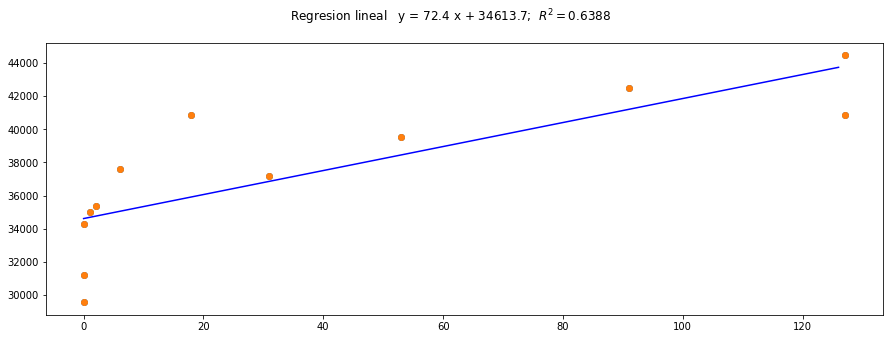

In [24]:



# Polynomial Regression
def polyfit(x, y, degree):
    results = {}

    coeffs = np.polyfit(x, y, degree)

     # Polynomial Coefficients
    results['polynomial'] = coeffs.tolist()

    # r-squared
    p = np.poly1d(coeffs)
    # fit values, and mean
    yhat = p(x)                         # or [p(z) for z in x]
    ybar = np.sum(y)/len(y)          # or sum(y)/len(y)
    ssreg = np.sum((yhat-ybar)**2)   # or sum([ (yihat - ybar)**2 for yihat in yhat])
    sstot = np.sum((y - ybar)**2)    # or sum([ (yi - ybar)**2 for yi in y])
    results['determination'] = ssreg / sstot

    return results
degree=1
model=np.polyfit(x, y, degree)
predict = np.poly1d(model)
model1= polyfit(x, y, degree)
m=round(model1['polynomial'][0],1)
b=round(model1['polynomial'][1],1)
R2=round(model1['determination'],4)


tt='Regresion lineal   y = '+str(m)+' x + '+str(b)+';  $R^2=$'+str(R2)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax = plt.scatter(x,y)
ax = plt.suptitle(tt)
# ax = plt.ylabel("kwh")
x_lin_reg = range(0, x.max())
y_lin_reg = predict(x_lin_reg)
ax = plt.scatter(x, y)
ax = plt.plot(x_lin_reg, y_lin_reg, c = 'b')

img = BytesIO()
plt.savefig(img, format='png')
img.seek(0)
plot_url = base64.b64encode(img.getvalue()).decode()
dfa_g = ('<img src="data:image/png;base64,{}">'.format(plot_url))
# plt.close()